# Week 15 — Monday (Jul 1): GAN Theory

## Learning Objectives
- Understand the adversarial game between Generator and Discriminator
- Derive the minimax loss and understand Nash equilibrium in GANs
- Know the four main failure modes: mode collapse, vanishing gradients, oscillation, memorisation
- Implement a Vanilla GAN from scratch and train it on MNIST
- Understand why GANs are hard to train and what tricks help

## Key Concepts
1. **Generator (G)** — maps random noise z → fake image; wants to fool D
2. **Discriminator (D)** — classifies real vs fake; wants to catch G
3. **Minimax game** — G and D play against each other until Nash equilibrium
4. **Mode collapse** — G ignores z and always generates the same output
5. **Training tricks** — label smoothing, separate optimizers, balanced updates

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms

plt.rcParams['figure.figsize'] = (14, 6)
np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {DEVICE}')
print('Week 15 — GAN Theory')

PyTorch 2.12.0+cpu | Device: cpu
Week 15 — GAN Theory


## Section 1: The Adversarial Game

A GAN consists of two networks playing a minimax game:

```
  Random noise z                      Real images x
  (latent vector)                     (training data)
       │                                    │
       ▼                                    │
  ┌─────────┐   fake images x̂             │
  │Generator│ ─────────────────────────►  ┌─────────────────┐
  │  G(z)   │                             │  Discriminator  │ ──► Real/Fake score
  └─────────┘                             │     D(x)        │
                                     ───► └─────────────────┘
  G wants D to output 1 for fake          D wants 1 for real, 0 for fake
  (G minimises loss)                      (D maximises accuracy)
```

### Minimax Objective
$$\min_G \max_D \; V(G,D) = \mathbb{E}_{x \sim p_{data}}[\log D(x)] + \mathbb{E}_{z \sim p_z}[\log(1 - D(G(z)))]$$

- **D maximises**: log D(real) should be high + log(1-D(fake)) should be high
- **G minimises**: log(1-D(G(z))) should be low → D(G(z)) should be high (fool D)

### Nash Equilibrium
Training converges when:
- $p_G = p_{data}$ — generated distribution matches real data
- $D(x) = 0.5$ everywhere — D can no longer tell real from fake

### G's Alternative Loss (used in practice)
Original: $\min_G \log(1 - D(G(z)))$ — saturates early, weak gradients

Alternative: $\max_G \log(D(G(z)))$ — non-saturating, stronger gradients for G

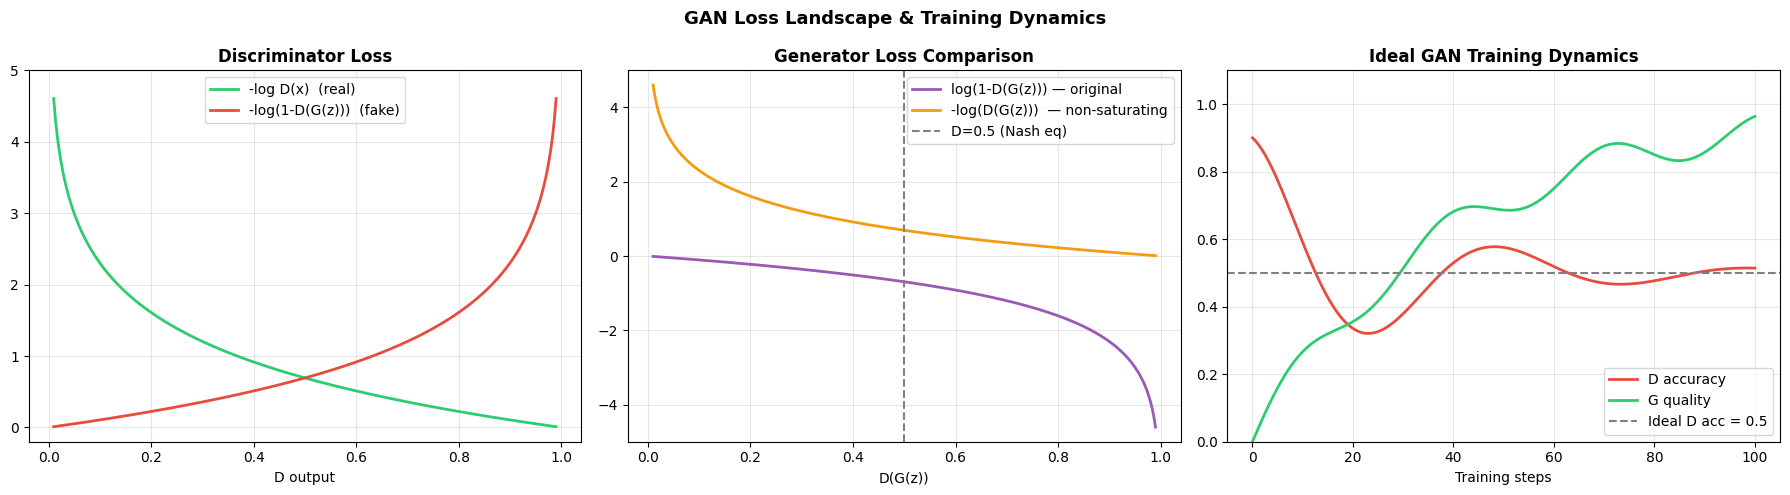

Saved gan_loss_landscape.png


In [2]:
# ── Visualise GAN loss landscape ──────────────────────────────────────────────
d_out = np.linspace(0.01, 0.99, 300)

# Discriminator losses
d_real_loss = -np.log(d_out)           # D on real: want D(x)=1
d_fake_loss = -np.log(1 - d_out)       # D on fake: want D(G(z))=0

# Generator losses
g_original = np.log(1 - d_out)        # original: minimise log(1-D(G(z)))
g_ns       = -np.log(d_out)           # non-saturating: maximise log(D(G(z)))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(d_out, d_real_loss, color='#2ecc71', lw=2, label='-log D(x)  (real)')
axes[0].plot(d_out, d_fake_loss, color='#e74c3c', lw=2, label='-log(1-D(G(z)))  (fake)')
axes[0].set_xlabel('D output'); axes[0].set_ylim(-0.2, 5)
axes[0].set_title('Discriminator Loss', fontweight='bold'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(d_out, g_original, color='#9b59b6', lw=2, label='log(1-D(G(z))) — original')
axes[1].plot(d_out, g_ns,       color='#f39c12', lw=2, label='-log(D(G(z)))  — non-saturating')
axes[1].axvline(0.5, color='grey', ls='--', label='D=0.5 (Nash eq)')
axes[1].set_xlabel('D(G(z))'); axes[1].set_ylim(-5, 5)
axes[1].set_title('Generator Loss Comparison', fontweight='bold'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Training dynamics illustration
epochs_demo = np.linspace(0, 100, 300)
d_acc  = 0.5 + 0.4 * np.exp(-epochs_demo/30) * np.cos(epochs_demo/8)
g_qual = 1 - np.exp(-epochs_demo/40) + 0.05 * np.sin(epochs_demo/5)
axes[2].plot(epochs_demo, np.clip(d_acc, 0, 1),  color='#e74c3c', lw=2, label='D accuracy')
axes[2].plot(epochs_demo, np.clip(g_qual, 0, 1), color='#2ecc71', lw=2, label='G quality')
axes[2].axhline(0.5, color='grey', ls='--', label='Ideal D acc = 0.5')
axes[2].set_xlabel('Training steps'); axes[2].set_title('Ideal GAN Training Dynamics', fontweight='bold')
axes[2].legend(); axes[2].grid(True, alpha=0.3); axes[2].set_ylim(0, 1.1)

plt.suptitle('GAN Loss Landscape & Training Dynamics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('gan_loss_landscape.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved gan_loss_landscape.png')

## Section 2: GAN Failure Modes

| Failure | What happens | Why | Fix |
|---------|-------------|-----|-----|
| **Mode collapse** | G always generates same image regardless of z | G found one mode that fools D | Minibatch discrimination, WGAN, diverse z |
| **Vanishing gradients** | G stops learning, D too strong | log(1-D(G(z))) saturates near 0 | Non-saturating loss, reduce D learning |
| **Oscillation** | D and G cycle without converging | Adversarial dynamics unstable | Spectral norm, gradient penalty |
| **Memorisation** | G copies training images | D too weak or dataset too small | More data, add noise, stronger D |

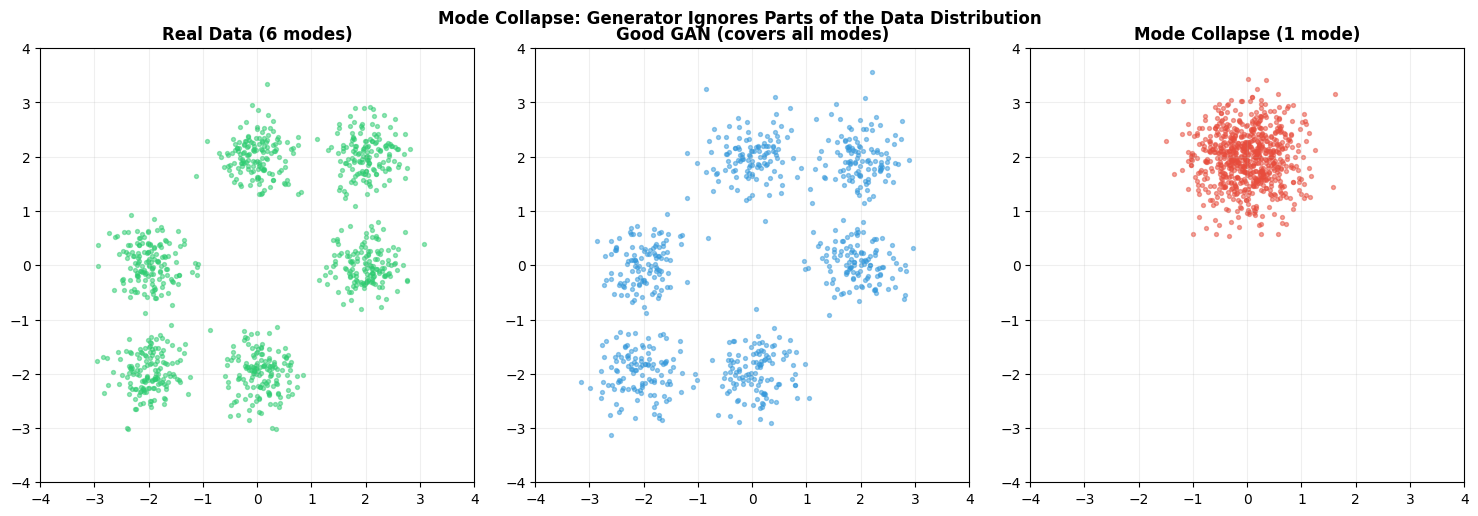

Saved mode_collapse.png


In [3]:
# ── Visualise mode collapse ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Real data: multi-modal (6 clusters)
np.random.seed(42)
centres = [(0,2),(2,0),(-2,0),(0,-2),(2,2),(-2,-2)]
real_pts = np.vstack([np.random.randn(150,2)*0.35 + c for c in centres])

# Good GAN: covers all modes
good_pts = np.vstack([np.random.randn(120,2)*0.4 + c for c in centres])

# Mode collapse: only one mode generated
collapsed_pts = np.random.randn(700,2)*0.5 + centres[0]

for ax, pts, title, clr in zip(axes,
    [real_pts, good_pts, collapsed_pts],
    ['Real Data (6 modes)', 'Good GAN (covers all modes)', 'Mode Collapse (1 mode)'],
    ['#2ecc71', '#3498db', '#e74c3c']):
    ax.scatter(pts[:,0], pts[:,1], s=8, alpha=0.5, color=clr)
    ax.set_title(title, fontweight='bold'); ax.set_xlim(-4,4); ax.set_ylim(-4,4)
    ax.grid(True, alpha=0.2); ax.set_aspect('equal')

plt.suptitle('Mode Collapse: Generator Ignores Parts of the Data Distribution',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('mode_collapse.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved mode_collapse.png')

## Section 3: Vanilla GAN — Implementation on MNIST

  0%|          | 0.00/9.91M [00:00<?, ?B/s]

  0%|          | 32.8k/9.91M [00:00<01:31, 108kB/s]

  1%|          | 98.3k/9.91M [00:00<01:23, 118kB/s]

  2%|▏         | 164k/9.91M [00:01<01:08, 143kB/s] 

  2%|▏         | 229k/9.91M [00:01<01:25, 113kB/s]

...

 95%|█████████▌| 1.57M/1.65M [00:04<00:00, 258kB/s]

100%|██████████| 1.65M/1.65M [00:04<00:00, 343kB/s]

  0%|          | 0.00/4.54k [00:00<?, ?B/s]

100%|██████████| 4.54k/4.54k [00:00<00:00, 1.94MB/s]

MNIST loaded: 2000 samples | 15 batches/epoch


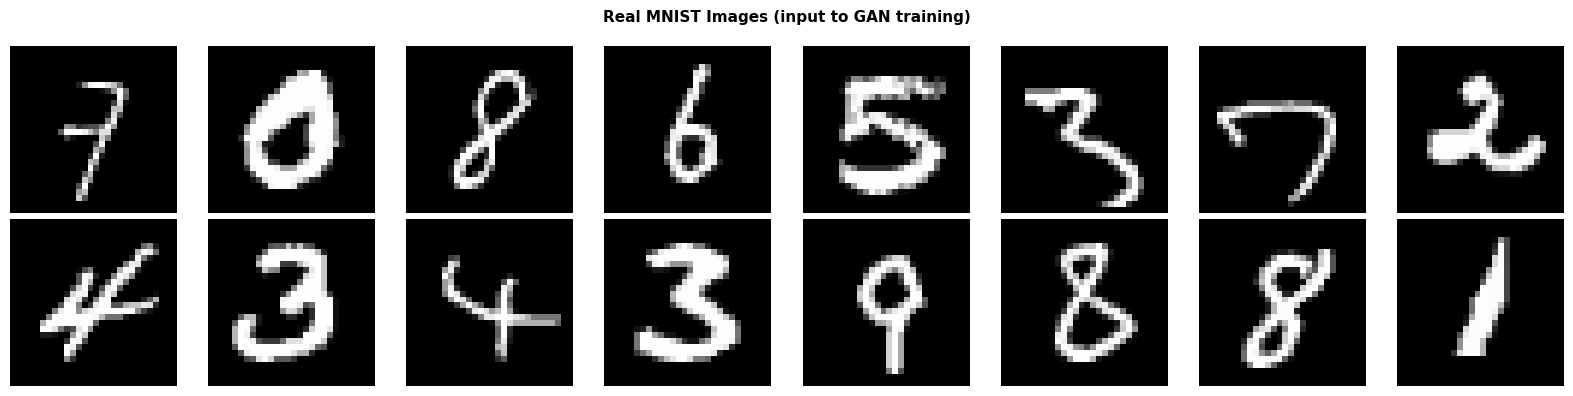

In [4]:
# ── Hyper-parameters ──────────────────────────────────────────────────────────
Z_DIM      = 100    # latent noise dimension
IMG_DIM    = 28*28  # MNIST image size
BATCH_SIZE = 128
N_EPOCHS   = 8
LR         = 2e-4
N_SAMPLES  = 2000   # subset of MNIST for CPU speed

# ── MNIST dataset ─────────────────────────────────────────────────────────────
tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # scale to [-1, 1] for Tanh output
])
full_ds = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=tf)
train_ds = Subset(full_ds, list(range(N_SAMPLES)))
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
print(f'MNIST loaded: {N_SAMPLES} samples | {len(train_dl)} batches/epoch')

# ── Show real samples ─────────────────────────────────────────────────────────
real_imgs, _ = next(iter(train_dl))
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(16):
    axes[i//8, i%8].imshow(real_imgs[i,0].numpy(), cmap='gray', vmin=-1, vmax=1)
    axes[i//8, i%8].axis('off')
plt.suptitle('Real MNIST Images (input to GAN training)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('real_mnist.png', dpi=100, bbox_inches='tight')
plt.show()

In [5]:
# ── Generator ─────────────────────────────────────────────────────────────────
class Generator(nn.Module):
    """
    Fully-connected GAN generator.
    z (100,) → hidden layers → IMG_DIM → reshape to (1,28,28)
    Tanh output: maps to [-1,1] to match normalised MNIST
    """
    def __init__(self, z_dim, img_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 512),   nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),  nn.LeakyReLU(0.2),
            nn.Linear(1024, img_dim), nn.Tanh()
        )
    def forward(self, z): return self.net(z)


class Discriminator(nn.Module):
    """
    Fully-connected GAN discriminator.
    Image (784,) → hidden layers → scalar probability of being real
    Sigmoid output: probability in (0, 1)
    """
    def __init__(self, img_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(img_dim, 1024), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(1024, 512),     nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(512, 256),      nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(256, 1),        nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)


G = Generator(Z_DIM, IMG_DIM).to(DEVICE)
D = Discriminator(IMG_DIM).to(DEVICE)
print(f'Generator     params: {sum(p.numel() for p in G.parameters()):,}')
print(f'Discriminator params: {sum(p.numel() for p in D.parameters()):,}')

# Test forward pass
z_test = torch.randn(4, Z_DIM).to(DEVICE)
fake   = G(z_test)
score  = D(fake)
print(f'Noise: {tuple(z_test.shape)} → Fake: {tuple(fake.shape)} → D score: {tuple(score.shape)}')

Generator     params: 1,486,352
Discriminator params: 1,460,225
Noise: (4, 100) → Fake: (4, 784) → D score: (4, 1)


In [6]:
# ── Training loop ─────────────────────────────────────────────────────────────
criterion  = nn.BCELoss()
opt_G      = torch.optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
opt_D      = torch.optim.Adam(D.parameters(), lr=LR, betas=(0.5, 0.999))

# Fixed noise for consistent visualisation across epochs
fixed_z = torch.randn(16, Z_DIM).to(DEVICE)

history = {'d_loss': [], 'g_loss': [], 'd_real': [], 'd_fake': []}

for epoch in range(1, N_EPOCHS + 1):
    ep_d, ep_g, ep_dr, ep_df = [], [], [], []

    for real_imgs, _ in train_dl:
        real_imgs = real_imgs.view(-1, IMG_DIM).to(DEVICE)
        bs        = real_imgs.size(0)

        # ── Train Discriminator ───────────────────────────────────────────────
        # Label smoothing: real=0.9 instead of 1.0 (helps stability)
        real_labels = torch.full((bs, 1), 0.9).to(DEVICE)
        fake_labels = torch.zeros(bs, 1).to(DEVICE)

        z    = torch.randn(bs, Z_DIM).to(DEVICE)
        fake = G(z).detach()   # detach: don't backprop through G here

        d_real = D(real_imgs)
        d_fake = D(fake)
        loss_D = criterion(d_real, real_labels) + criterion(d_fake, fake_labels)

        opt_D.zero_grad(); loss_D.backward(); opt_D.step()

        # ── Train Generator ───────────────────────────────────────────────────
        # Non-saturating loss: G wants D(G(z)) = 1
        z    = torch.randn(bs, Z_DIM).to(DEVICE)
        fake = G(z)
        loss_G = criterion(D(fake), torch.ones(bs, 1).to(DEVICE))

        opt_G.zero_grad(); loss_G.backward(); opt_G.step()

        ep_d.append(loss_D.item()); ep_g.append(loss_G.item())
        ep_dr.append(d_real.mean().item()); ep_df.append(d_fake.mean().item())

    history['d_loss'].append(np.mean(ep_d)); history['g_loss'].append(np.mean(ep_g))
    history['d_real'].append(np.mean(ep_dr)); history['d_fake'].append(np.mean(ep_df))
    print(f'Epoch {epoch:2d}/{N_EPOCHS} | D loss: {history["d_loss"][-1]:.4f} | '
          f'G loss: {history["g_loss"][-1]:.4f} | '
          f'D(real)={history["d_real"][-1]:.3f}  D(fake)={history["d_fake"][-1]:.3f}')

print('\nTraining complete.')
print('Ideal: D(real)→0.9  D(fake)→0.5  (Nash equilibrium approaching)')

Epoch  1/8 | D loss: 1.1756 | G loss: 0.6892 | D(real)=0.745  D(fake)=0.526


Epoch  2/8 | D loss: 1.2577 | G loss: 0.8726 | D(real)=0.673  D(fake)=0.542


Epoch  3/8 | D loss: 1.1723 | G loss: 0.9049 | D(real)=0.771  D(fake)=0.540


Epoch  4/8 | D loss: 1.0353 | G loss: 0.9095 | D(real)=0.803  D(fake)=0.485


Epoch  5/8 | D loss: 1.2870 | G loss: 0.8832 | D(real)=0.662  D(fake)=0.527


Epoch  6/8 | D loss: 1.3526 | G loss: 0.9693 | D(real)=0.594  D(fake)=0.521


Epoch  7/8 | D loss: 1.1616 | G loss: 1.1285 | D(real)=0.642  D(fake)=0.463


Epoch  8/8 | D loss: 1.0363 | G loss: 1.1575 | D(real)=0.727  D(fake)=0.443

Training complete.
Ideal: D(real)→0.9  D(fake)→0.5  (Nash equilibrium approaching)


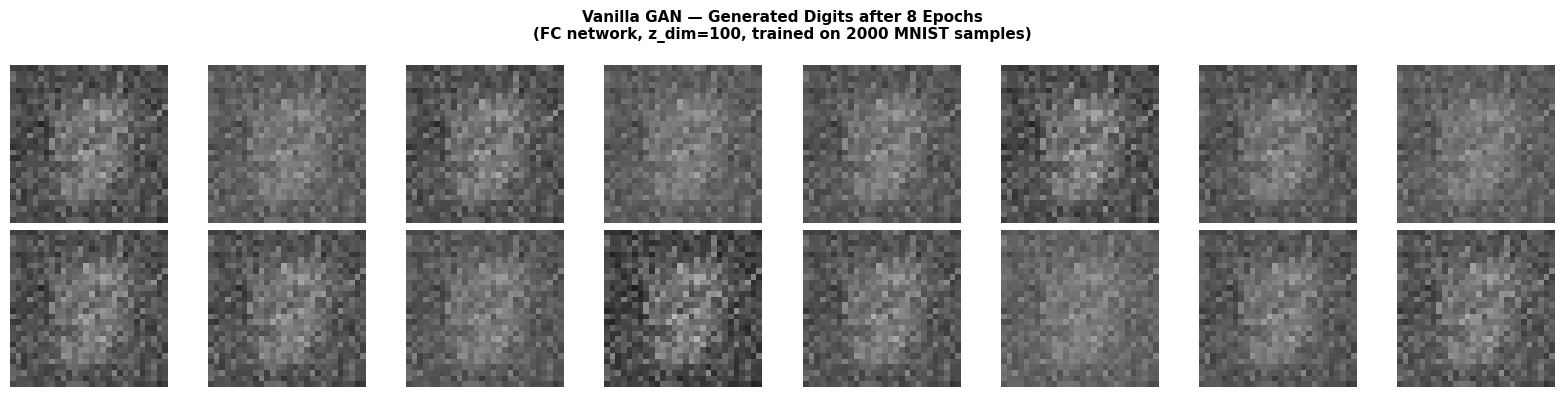

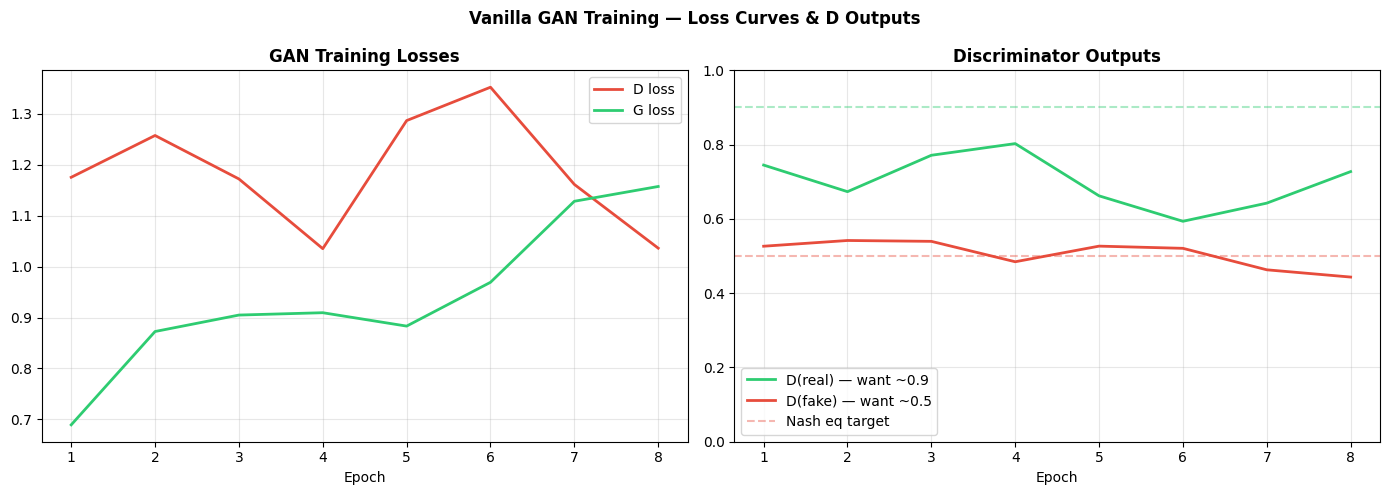

Saved gan_generated.png  gan_training_curves.png


In [7]:
# ── Generated samples ─────────────────────────────────────────────────────────
G.eval()
with torch.no_grad():
    gen_imgs = G(fixed_z).cpu().view(16, 28, 28)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(16):
    axes[i//8, i%8].imshow(gen_imgs[i].numpy(), cmap='gray', vmin=-1, vmax=1)
    axes[i//8, i%8].axis('off')
plt.suptitle(f'Vanilla GAN — Generated Digits after {N_EPOCHS} Epochs\n'
             f'(FC network, z_dim={Z_DIM}, trained on {N_SAMPLES} MNIST samples)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('gan_generated.png', dpi=100, bbox_inches='tight')
plt.show()

# ── Training curves ───────────────────────────────────────────────────────────
ep = range(1, N_EPOCHS+1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ep, history['d_loss'], label='D loss', color='#e74c3c', lw=2)
axes[0].plot(ep, history['g_loss'], label='G loss', color='#2ecc71', lw=2)
axes[0].set_title('GAN Training Losses', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, history['d_real'], label='D(real) — want ~0.9', color='#2ecc71', lw=2)
axes[1].plot(ep, history['d_fake'], label='D(fake) — want ~0.5', color='#e74c3c', lw=2)
axes[1].axhline(0.9, color='#2ecc71', ls='--', alpha=0.4)
axes[1].axhline(0.5, color='#e74c3c', ls='--', alpha=0.4, label='Nash eq target')
axes[1].set_title('Discriminator Outputs', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Vanilla GAN Training — Loss Curves & D Outputs', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('gan_training_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved gan_generated.png  gan_training_curves.png')

## Key Takeaways

| Concept | Summary |
|---------|--------|
| **Minimax game** | G and D compete — G fools D, D catches G |
| **Nash equilibrium** | Ideal end state: G matches real distribution, D outputs 0.5 everywhere |
| **Non-saturating loss** | `max log D(G(z))` instead of `min log(1-D(G(z)))` — stronger early gradients |
| **Label smoothing** | Use 0.9 for real labels instead of 1.0 — prevents D from becoming overconfident |
| **Adam betas=(0.5, 0.999)** | Standard for GAN training — lower beta1 means faster momentum decay |
| **Mode collapse** | G finds one output that always fools D — diversity of z is ignored |
| **D(real)→0.9, D(fake)→0.5** | What to watch during training — if D(fake)→0, G has stopped learning |

### Exercises
1. Remove label smoothing and observe what happens to training stability.
2. Train the same model for 20 epochs — does quality improve or do you see mode collapse?
3. Add BatchNorm to the Generator and compare generated image quality.
4. Try training on all 60,000 MNIST samples — how much better does the output get?
5. Implement the Wasserstein GAN loss (remove Sigmoid from D, use weight clipping) and compare stability.